<a href="https://colab.research.google.com/github/JulianSantos-LATAMAI/card-krueger-replication/blob/main/notebooks/03_Extension_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Julián Santos

ECON 5200 Midterm project

Phase 3: Extension


In [54]:
import pandas as pd
import numpy as np

In [55]:
from google.colab import files
uploaded = files.upload()

Saving public.dat to public (1).dat


In [56]:
FILEPATH = '/content/public.dat'
df = pd.read_csv(FILEPATH)
print(df.head())

  46 1 0 0 0 0 0 1 0 0  0 30.00 15.00  3.00   .    19.0   .   1    .  2  6.50 16.50  1.03  1.03  0.52  3  3 1 1 111792  1  3.50 35.00  3.00  4.30  26.0  0.08 1 2  6.50 16.50  1.03   .    0.94  4  4    
0   49 2 0 0 0 0 0 1 0 0  0  6.50  6.50  4.00   ....                                                                                                                                                     
1  506 2 1 0 0 0 0 1 0 0  0  3.00  7.00  2.00   ....                                                                                                                                                     
2   56 4 1 0 0 0 0 1 0 0  0 20.00 20.00  4.00  5....                                                                                                                                                     
3   61 4 1 0 0 0 0 1 0 0  0  6.00 26.00  5.00  5....                                                                                                                                            

In [57]:
# Read all columns EXCEPT WAGE_ST2 using original specs
col_specs_main = [
    (0, 3),(3, 5),(5, 7),(7, 9),(9, 11),(11, 13),(13, 15),(15, 17),(17, 19),
    (19, 21),(21, 24),(24, 30),(30, 36),(36, 42),(42, 48),(48, 54),(54, 58),
    (58, 62),(62, 67),(67, 69),(69, 73),(73, 82),(82, 88),(88, 94),(94, 100),
    (100, 103),(103, 107),(107, 109),(109, 111),(111, 117),(117, 120),
    (120, 126),(126, 132),(132, 138),
    (144, 150),(150, 154),(154, 160),(160, 166),(166, 172),(172, 178),
    (178, 181),(181, 185),(185, 191),(191, 195)
]


col_names_main = [
    'SHEET','CHAIN','CO_OWNED','STATE','SOUTHJ','CENTRALJ','NORTHJ',
    'PA1','PA2','SHORE','NCALLS','EMPFT','EMPPT','NMGRS','WAGE_ST',
    'INCTIME','FIRSTINC','BONUS','PCTAFF','MEALS','OPEN','HRSOPEN',
    'PSODA','PFRY','PENTREE','NREGS','NREGS11','EMPFT2','EMPPT2',
    'DATE','NMGRS2','INCTIME2','FIRSTIN2','BONUS2',
    'PCTAFF2','MEALS2','OPEN2R','HRSOPEN2','PSODA2','PFRY2',
    'PENTREE2','NREGS2','NREGS112','PSODA3'
]

# Read WAGE_ST2 in isolation (confirmed working)
df_main = pd.read_fwf('/content/public.dat', colspecs=col_specs_main,
                      names=col_names_main, na_values='.')

df_w2   = pd.read_fwf('/content/public.dat', colspecs=[(42,48),(138,144)],
                      names=['WAGE_ST','WAGE_ST2'], na_values='.')

# Merge on index
df = df_main.copy()
df['WAGE_ST2'] = df_w2['WAGE_ST2'].values

print(df.head())

   SHEET  CHAIN  CO_OWNED  STATE  SOUTHJ  CENTRALJ  NORTHJ  PA1  PA2  SHORE  \
0     46      1         0      0       0         0       0    1    0      0   
1     49      2         0      0       0         0       0    1    0      0   
2    506      2         1      0       0         0       0    1    0      0   
3     56      4         1      0       0         0       0    1    0      0   
4     61      4         1      0       0         0       0    1    0      0   

   ...  MEALS2  OPEN2R  HRSOPEN2  PSODA2  PFRY2  PENTREE2  NREGS2 NREGS112  \
0  ...     0.0  08 1 2       6.5    16.5   1.03       NaN     NaN     0.94   
1  ...     0.0  05 0 2      10.0    13.0   1.01       0.0    0.89     2.35   
2  ...     0.0  25 . 1      11.0    11.0   0.95       0.0    0.74     2.33   
3  ...     0.0  15 0 2      10.0    12.0   0.92       0.0    0.79     0.87   
4  ...     0.0  15 0 2      10.0    12.0   1.01       0.0    0.84     0.95   

   PSODA3  WAGE_ST2  
0     4.0      4.30  
1     4.0   

In [58]:
#Descriptive Table Reconstruction

# Building FTE variables
#FTE (Full Time Equivalent) = full time employees + 0.5 * part time employees + managers.

df['FTE']  = df['EMPFT']  + 0.5 * df['EMPPT']  + df['NMGRS']
df['FTE2'] = df['EMPFT2'] + 0.5 * df['EMPPT2'] + df['NMGRS2']
df['TREAT'] = df['STATE']

# Table Construction: Finding STDV and Mean
variables_w1 = ['FTE', 'WAGE_ST', 'PSODA', 'PFRY', 'PENTREE']
variables_w2 = ['FTE2', 'WAGE_ST2', 'PSODA2', 'PFRY2', 'PENTREE2']

means_w1 = df.groupby('STATE')[variables_w1].mean().round(2)
stds_w1  = df.groupby('STATE')[variables_w1].std().round(2)
means_w2 = df.groupby('STATE')[variables_w2].mean().round(2)
stds_w2  = df.groupby('STATE')[variables_w2].std().round(2)

table2 = pd.DataFrame({
    ('Wave 1 (Before)', 'NJ Mean'): means_w1.loc[1].values,
    ('Wave 1 (Before)', 'NJ Std'):  stds_w1.loc[1].values,
    ('Wave 1 (Before)', 'PA Mean'): means_w1.loc[0].values,
    ('Wave 1 (Before)', 'PA Std'):  stds_w1.loc[0].values,
    ('Wave 2 (After)',  'NJ Mean'): means_w2.loc[1].values,
    ('Wave 2 (After)',  'NJ Std'):  stds_w2.loc[1].values,
    ('Wave 2 (After)',  'PA Mean'): means_w2.loc[0].values,
    ('Wave 2 (After)',  'PA Std'):  stds_w2.loc[0].values,
}, index=['FTE', 'WAGE_ST', 'PSODA', 'PFRY', 'PENTREE'])

print(table2.to_string())

        Wave 1 (Before)                       Wave 2 (After)                      
                NJ Mean NJ Std PA Mean PA Std        NJ Mean NJ Std PA Mean PA Std
FTE               20.44   9.11   23.33  11.86           4.16   2.19    3.44   1.34
WAGE_ST            4.61   0.35    4.63   0.35           5.08   0.10    4.62   0.36
PSODA              1.06   0.08    0.97   0.07          14.42   2.72   14.65   2.89
PFRY               0.94   0.10    0.84   0.09           1.06   0.09    0.98   0.08
PENTREE            1.35   0.65    1.22   0.62           0.42   0.49    0.19   0.40


Building on the baseline Card and Krueger (1994) difference-in-differences replication,
this extension pursues Pathway 2 by testing for heterogeneous treatment effects along
two dimensions the original paper controlled for but never interrogated: store ownership
type and the regional political environment in which stores operate.

**Ownership Type**

Card and Krueger include a company-ownership dummy as a control variable in their
reduced-form employment models, but they do not test whether the employment or wage
response to the minimum wage differed between company-owned stores and franchisee-operated
stores. This is a theoretically meaningful distinction. Franchisees operate under fixed
contractual obligations to their parent chains, face tighter profit margins, and lack
access to the cross-subsidization that corporate ownership structures can provide when
absorbing an unexpected labor cost shock. A company-owned store, by contrast, can
potentially draw on broader organizational resources to maintain or even expand staffing
levels and adjust wages following a binding minimum wage increase. To test this, two
interaction terms are introduced into the baseline models: first, the product of the
New Jersey dummy and the company-ownership indicator (NJ × Company-owned), which captures
whether company-owned stores in the treated state experienced a differential wage or
employment change relative to franchisees; and second, the product of the wage GAP
variable and the company-ownership indicator (GAP × Company-owned), which tests whether
stores facing a larger mandated wage increase responded differently depending on ownership
structure.

**Regional Political Lean**

The second dimension introduced in this extension is the regional political environment
in which each store operates. While the minimum wage mandate applied uniformly across
New Jersey, local political context may plausibly moderate how quickly or fully stores
complied with the new floor. Stores located in politically conservative regions —
historically more opposed to minimum wage legislation — may have exhibited slower
adjustment, greater resistance, or differential wage-setting behavior relative to stores
in more liberal regions where the policy enjoyed broader popular support. To operationalize
this, a political lean proxy is constructed from the regional indicators already present
in the Card and Krueger public dataset. South Jersey (SOUTHJ) and rural Pennsylvania (PA2)
are classified as conservative-leaning, consistent with historical voting patterns in the
1988 and 1992 presidential elections. North Jersey (NORTHJ), the Jersey Shore (SHORE),
and urban eastern Pennsylvania (PA1) are classified as liberal-leaning. Central Jersey
(CENTRALJ) is treated as a swing region and flagged separately for robustness checks.
Two additional interaction terms are then introduced: the product of the New Jersey dummy
and the conservative region indicator (NJ × Conservative Region), and the product of the
wage GAP variable and the conservative region indicator (GAP × Conservative Region), both
of which test whether the starting wage response to the mandate differed systematically
by local political context.

**Joint Specification**

A joint model is also estimated that includes both the ownership and political lean
interaction terms simultaneously, allowing for an assessment of whether the two dimensions
operate independently or whether their effects are confounded. All specifications retain
the original chain-type controls and use heteroskedasticity-robust standard errors (HC1)
throughout. Given the relatively small cell sizes in some ownership-by-region subgroups —
particularly conservative-region company-owned stores — results from the joint model
should be interpreted with caution, and VIF diagnostics are recommended to assess
multicollinearity among the interaction terms.

In [59]:
# =============================================================================
# PHASE 4 EXTENSION — FEATURE ENGINEERING
# New dimensions: (1) Ownership type on wages  (2) Regional political lean
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Reuse plot theme from Phase 3 ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',   'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#e0e0e0',      'ytick.color': '#e0e0e0',
    'text.color': '#e0e0e0',       'grid.color': '#0f3460',
    'grid.linestyle': '--',        'grid.alpha': 0.7,
    'font.family': 'DejaVu Sans',  'axes.titlesize': 13,
    'axes.labelsize': 11,          'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

COLORS = {
    'nj':           '#e94560',
    'pa':           '#0f9b8e',
    'franchise':    '#f5a623',
    'company':      '#7b68ee',
    'conservative': '#e07b54',
    'liberal':      '#54a0e0',
    'overall':      '#e0e0e0',
    'zero_line':    '#ff4444',
    'ci':           '#4a90d9',
}


def engineer_phase4_features(df):
    """
    Adds Phase 4 variables on top of any existing Phase 3 features.
    Safe to call on the raw dataframe — all column names are lower-cased first.
    """
    df.columns = df.columns.str.lower()

    # ── Core DiD variables (reconstruct if not already present) ──────────────
    if 'fte1' not in df.columns:
        df['fte1'] = df['empft'] + 0.5 * df['emppt'] + df.get('nmgrs', 0)
    if 'fte2' not in df.columns:
        df['fte2'] = df['empft2'] + 0.5 * df['emppt2'] + df.get('nmgrs2', 0)
    if 'delta_fte' not in df.columns:
        df['delta_fte'] = df['fte2'] - df['fte1']
    if 'nj' not in df.columns:
        df['nj'] = df['state'].astype(int)
    if 'gap' not in df.columns:
        df['gap'] = np.where(
            df['nj'] == 1,
            np.maximum(0, (5.05 - df['wage_st']) / df['wage_st']),
            0.0
        )
    df['co_owned'] = df['co_owned'].astype(int)
    df['franchise'] = 1 - df['co_owned']

    # ── Chain dummies ─────────────────────────────────────────────────────────
    for c in [2, 3, 4]:
        df[f'chain{c}'] = (df['chain'] == c).astype(int)

    # ── Balanced sample flag ──────────────────────────────────────────────────
    closed = df.get('closed', pd.Series(0, index=df.index))
    df['balanced'] = (df['fte1'].notna() & df['fte2'].notna() & (closed == 0)).astype(int)

    # ──────────────────────────────────────────────────────────────────────────
    # POLITICAL LEAN PROXY
    # Regional dummies in the C&K public codebook:
    #   SOUTHJ=1   → South Jersey     (conservative lean)
    #   CENTRALJ=1 → Central Jersey   (swing/moderate)
    #   NORTHJ=1   → North Jersey     (liberal lean)
    #   PA1=1      → Eastern PA       (Philadelphia metro — liberal lean)
    #   PA2=1      → Western PA       (Pittsburgh/rural — conservative lean)
    #   SHORE=1    → Jersey Shore     (moderate-to-liberal lean)
    # ──────────────────────────────────────────────────────────────────────────

    region_cols = ['southj', 'centralj', 'northj', 'pa1', 'pa2', 'shore']
    for col in region_cols:
        if col not in df.columns:
            df[col] = 0  # graceful fallback

    df['conservative_region'] = (
        (df['southj'] == 1) | (df['pa2'] == 1)
    ).astype(int)

    df['liberal_region'] = (
        (df['northj'] == 1) | (df['pa1'] == 1) | (df['shore'] == 1)
    ).astype(int)

    df['swing_region'] = (
        (df['centralj'] == 1) & (df['conservative_region'] == 0) & (df['liberal_region'] == 0)
    ).astype(int)

    # ── Wage change variable ──────────────────────────────────────────────────
    if 'wage_st2' in df.columns:
        df['delta_wage'] = df['wage_st2'] - df['wage_st']
    else:
        df['delta_wage'] = np.nan

    # ── Interaction terms — ownership ─────────────────────────────────────────
    df['nj_x_coowned']    = df['nj']  * df['co_owned']
    df['gap_x_coowned']   = df['gap'] * df['co_owned']
    df['nj_x_franchise']  = df['nj']  * df['franchise']
    df['gap_x_franchise'] = df['gap'] * df['franchise']

    # ── Interaction terms — political lean ────────────────────────────────────
    df['nj_x_conserv']  = df['nj']  * df['conservative_region']
    df['gap_x_conserv'] = df['gap'] * df['conservative_region']
    df['nj_x_liberal']  = df['nj']  * df['liberal_region']
    df['gap_x_liberal'] = df['gap'] * df['liberal_region']

    # ── Three-way interaction ─────────────────────────────────────────────────
    df['nj_x_conserv_x_coowned'] = df['nj'] * df['conservative_region'] * df['co_owned']

    print("=" * 60)
    print("PHASE 4 FEATURE ENGINEERING COMPLETE")
    print("=" * 60)
    for grp, mask in [
        ('NJ — Conservative region', (df.nj==1) & (df.conservative_region==1)),
        ('NJ — Liberal region',      (df.nj==1) & (df.liberal_region==1)),
        ('NJ — Swing region',        (df.nj==1) & (df.swing_region==1)),
        ('PA — Conservative region', (df.nj==0) & (df.conservative_region==1)),
        ('PA — Liberal region',      (df.nj==0) & (df.liberal_region==1)),
    ]:
        sub = df[mask]
        print(f"  {grp:<35} n={len(sub):>4}  (company={sub['co_owned'].sum()}, franchise={sub['franchise'].sum()})")
    print()
    return df


# ── Run on existing df from Phase 3, or reload from scratch ──────────────────
# If running standalone:
#   raw = load_data('njmin.dta')
#   df  = engineer_phase4_features(raw)
# If continuing from Phase 3:
df = engineer_phase4_features(df)

PHASE 4 FEATURE ENGINEERING COMPLETE
  NJ — Conservative region            n=  93  (company=42, franchise=51)
  NJ — Liberal region                 n= 203  (company=66, franchise=137)
  NJ — Swing region                   n=  54  (company=10, franchise=44)
  PA — Conservative region            n=  43  (company=20, franchise=23)
  PA — Liberal region                 n=  36  (company=8, franchise=28)



In [60]:
# =============================================================================
# PHASE 4 — WAGE REGRESSIONS
# Outcome: WAGE_ST (Wave 1 starting wage)
# Set 1 — ownership interactions (CO_OWNED vs franchisee)
# Set 2 — political lean interactions (conservative vs liberal region)
# Set 3 — joint model
# =============================================================================

def wage_baseline_regressions(df):
    bal      = df[df['balanced'] == 1].copy()
    controls = 'chain2 + chain3 + chain4'

    specs = {
        'W1: NJ dummy only':           smf.ols('wage_st ~ nj', bal),
        'W2: NJ + chain controls':     smf.ols(f'wage_st ~ nj + {controls}', bal),
        'W3: NJ + ownership':          smf.ols(f'wage_st ~ nj + co_owned + {controls}', bal),
        'W4: NJ + region':             smf.ols(f'wage_st ~ nj + conservative_region + {controls}', bal),
        'W5: NJ + ownership + region': smf.ols(f'wage_st ~ nj + co_owned + conservative_region + {controls}', bal),
    }

    fitted = {name: m.fit(cov_type='HC1') for name, m in specs.items()}

    print("=" * 65)
    print("WAGE BASELINE MODELS — Dependent Variable: WAGE_ST (Wave 1)")
    print("Heteroskedasticity-Robust SE (HC1)")
    print("=" * 65)
    for v in ['nj', 'co_owned', 'conservative_region', 'Intercept']:
        row = f"{v:<28}"
        for res in fitted.values():
            if v in res.params:
                stars = ('***' if res.pvalues[v] < 0.01 else
                         '**'  if res.pvalues[v] < 0.05 else
                         '*'   if res.pvalues[v] < 0.10 else ' ')
                row += f"  {res.params[v]:+6.3f}{stars}"
            else:
                row += f"  {'—':>8}"
        print(row)
    print("-" * 65)
    print(f"{'N':28}" + "".join(f"  {int(r.nobs):>7}" for r in fitted.values()))
    print(f"{'R²':28}" + "".join(f"  {r.rsquared:>7.3f}" for r in fitted.values()))
    print("* p<0.10  ** p<0.05  *** p<0.01\n")
    return fitted


def wage_hte_regressions(df):
    """
    HTE wage models with interaction terms.

    SET 1 — Ownership × NJ/GAP
      Asks: Did company-owned stores in NJ set/raise wages differently
            than franchisees after the mandate?

    SET 2 — Political lean × NJ/GAP
      Asks: Did stores in conservative regions of NJ respond differently
            (e.g., more resistance to or slower compliance with the mandate)?

    SET 3 — Both dimensions jointly
    """
    bal      = df[df['balanced'] == 1].copy()
    controls = 'chain2 + chain3 + chain4'

    specs = {
        'HTE-O1: NJ × Ownership':
            smf.ols(f'wage_st ~ nj + co_owned + nj_x_coowned + {controls}', bal),

        'HTE-O2: GAP × Ownership':
            smf.ols(f'wage_st ~ gap + co_owned + gap_x_coowned + {controls}', bal),

        'HTE-P1: NJ × Conserv. Region':
            smf.ols(f'wage_st ~ nj + conservative_region + nj_x_conserv + {controls}', bal),

        'HTE-P2: GAP × Conserv. Region':
            smf.ols(f'wage_st ~ gap + conservative_region + gap_x_conserv + {controls}', bal),

        'HTE-J: NJ × Ownership + Region':
            smf.ols(
                'wage_st ~ nj + co_owned + conservative_region '
                '+ nj_x_coowned + nj_x_conserv '
                f'+ {controls}', bal),
    }

    fitted = {name: m.fit(cov_type='HC1') for name, m in specs.items()}

    print("=" * 65)
    print("PHASE 4 HTE WAGE MODELS — Dependent Variable: WAGE_ST")
    print("=" * 65)
    for name, res in fitted.items():
        print(f"\n{'─'*55}")
        print(f"Model: {name}")
        print(f"  N = {int(res.nobs)}, R² = {res.rsquared:.3f}, Adj-R² = {res.rsquared_adj:.3f}")
        for v in ['nj', 'gap', 'co_owned', 'conservative_region',
                  'nj_x_coowned', 'gap_x_coowned', 'nj_x_conserv', 'gap_x_conserv', 'Intercept']:
            if v in res.params:
                stars = ('***' if res.pvalues[v] < 0.01 else
                         '**'  if res.pvalues[v] < 0.05 else
                         '*'   if res.pvalues[v] < 0.10 else '')
                print(f"  {v:<28} {res.params[v]:+7.4f}  ({res.bse[v]:.4f}) {stars}")
    print()
    return fitted


def compute_implied_wages(hte_fitted):
    results = []

    # From HTE-O1: NJ × Ownership
    res = hte_fitted['HTE-O1: NJ × Ownership']
    b_nj, se_nj   = res.params.get('nj', np.nan), res.bse.get('nj', np.nan)
    b_own, se_own  = res.params.get('nj_x_coowned', np.nan), res.bse.get('nj_x_coowned', np.nan)
    cov12 = res.cov_params().loc['nj', 'nj_x_coowned'] \
            if ('nj' in res.cov_params().columns and 'nj_x_coowned' in res.cov_params().columns) else 0

    results.append({'Label': 'NJ Franchisee\n(ownership model)',
                    'Estimate': b_nj, 'SE': se_nj,
                    'Group': 'Ownership', 'Color': COLORS['franchise']})
    results.append({'Label': 'NJ Company-owned\n(ownership model)',
                    'Estimate': b_nj + b_own,
                    'SE': np.sqrt(se_nj**2 + se_own**2 + 2*cov12),
                    'Group': 'Ownership', 'Color': COLORS['company']})

    # From HTE-P1: NJ × Political lean
    res2 = hte_fitted['HTE-P1: NJ × Conserv. Region']
    b_nj2, se_nj2 = res2.params.get('nj', np.nan), res2.bse.get('nj', np.nan)
    b_pol, se_pol  = res2.params.get('nj_x_conserv', np.nan), res2.bse.get('nj_x_conserv', np.nan)
    cov_p = res2.cov_params().loc['nj', 'nj_x_conserv'] \
            if ('nj' in res2.cov_params().columns and 'nj_x_conserv' in res2.cov_params().columns) else 0

    results.append({'Label': 'NJ Liberal region\n(political lean model)',
                    'Estimate': b_nj2, 'SE': se_nj2,
                    'Group': 'Political Lean', 'Color': COLORS['liberal']})
    results.append({'Label': 'NJ Conservative region\n(political lean model)',
                    'Estimate': b_nj2 + b_pol,
                    'SE': np.sqrt(se_nj2**2 + se_pol**2 + 2*cov_p),
                    'Group': 'Political Lean', 'Color': COLORS['conservative']})

    # From joint model
    res3 = hte_fitted['HTE-J: NJ × Ownership + Region']
    for label, own_val, cons_val, color in [
        ('NJ Franchise, Liberal',      0, 0, COLORS['liberal']),
        ('NJ Company, Liberal',        1, 0, COLORS['company']),
        ('NJ Franchise, Conservative', 0, 1, COLORS['conservative']),
        ('NJ Company, Conservative',   1, 1, COLORS['franchise']),
    ]:
        b = (res3.params.get('nj', 0)
             + own_val  * res3.params.get('nj_x_coowned', 0)
             + cons_val * res3.params.get('nj_x_conserv', 0))
        se = np.sqrt(
            res3.bse.get('nj', 0)**2
            + (own_val  * res3.bse.get('nj_x_coowned', 0))**2
            + (cons_val * res3.bse.get('nj_x_conserv', 0))**2
        )
        results.append({'Label': label, 'Estimate': b, 'SE': se,
                        'Group': 'Joint Model', 'Color': color})

    out = pd.DataFrame(results)
    out['CI_lower']    = out['Estimate'] - 1.96 * out['SE']
    out['CI_upper']    = out['Estimate'] + 1.96 * out['SE']
    out['Significant'] = ~((out['CI_lower'] < 0) & (out['CI_upper'] > 0))
    return out


# ── Run ───────────────────────────────────────────────────────────────────────
wage_base    = wage_baseline_regressions(df)
wage_hte     = wage_hte_regressions(df)
implied_wage = compute_implied_wages(wage_hte)

WAGE BASELINE MODELS — Dependent Variable: WAGE_ST (Wave 1)
Heteroskedasticity-Robust SE (HC1)
nj                            -0.008   -0.002   -0.003   -0.005   -0.005 
co_owned                             —         —  -0.006          —  -0.006 
conservative_region                  —         —         —  -0.006   -0.005 
Intercept                     +4.667***  +4.645***  +4.646***  +4.649***  +4.649***
-----------------------------------------------------------------
N                                 150      150      150      150      150
R²                              0.000    0.008    0.008    0.008    0.008
* p<0.10  ** p<0.05  *** p<0.01

PHASE 4 HTE WAGE MODELS — Dependent Variable: WAGE_ST

───────────────────────────────────────────────────────
Model: HTE-O1: NJ × Ownership
  N = 150, R² = 0.022, Adj-R² = -0.019
  nj                           +0.0698  (0.0881) 
  co_owned                     +0.1706  (0.1350) 
  nj_x_coowned                 -0.2217  (0.1542) 
  Intercept     

In [61]:
# ── DIAGNOSTIC  ──────────────────
print("Column names:", df.columns.tolist())
print("\nRegion column dtypes:")
for col in ['southj', 'centralj', 'northj', 'pa1', 'pa2', 'shore']:
    if col in df.columns:
        print(f"  {col}: dtype={df[col].dtype}, unique={sorted(df[col].dropna().unique())}, nulls={df[col].isna().sum()}")
    else:
        print(f"  {col}: NOT FOUND")

print(f"\nwage_st2 present: {'wage_st2' in df.columns}")
if 'wage_st2' in df.columns:
    print(f"  dtype={df['wage_st2'].dtype}, nulls={df['wage_st2'].isna().sum()}, sample={df['wage_st2'].dropna().head(3).tolist()}")

print(f"\nTotal rows: {len(df)}")
print(df[['southj','centralj','northj','pa1','pa2','shore']].head(10))

Column names: ['sheet', 'chain', 'co_owned', 'state', 'southj', 'centralj', 'northj', 'pa1', 'pa2', 'shore', 'ncalls', 'empft', 'emppt', 'nmgrs', 'wage_st', 'inctime', 'firstinc', 'bonus', 'pctaff', 'meals', 'open', 'hrsopen', 'psoda', 'pfry', 'pentree', 'nregs', 'nregs11', 'empft2', 'emppt2', 'date', 'nmgrs2', 'inctime2', 'firstin2', 'bonus2', 'pctaff2', 'meals2', 'open2r', 'hrsopen2', 'psoda2', 'pfry2', 'pentree2', 'nregs2', 'nregs112', 'psoda3', 'wage_st2', 'fte', 'fte2', 'treat', 'fte1', 'delta_fte', 'nj', 'gap', 'franchise', 'chain2', 'chain3', 'chain4', 'balanced', 'conservative_region', 'liberal_region', 'swing_region', 'delta_wage', 'nj_x_coowned', 'gap_x_coowned', 'nj_x_franchise', 'gap_x_franchise', 'nj_x_conserv', 'gap_x_conserv', 'nj_x_liberal', 'gap_x_liberal', 'nj_x_conserv_x_coowned']

Region column dtypes:
  southj: dtype=int64, unique=[np.int64(0), np.int64(1)], nulls=0
  centralj: dtype=int64, unique=[np.int64(0), np.int64(1)], nulls=0
  northj: dtype=int64, unique=[n

In [62]:
print("wage_st2 stats:")
print(df['wage_st2'].describe())
print("\nValues above $6.00 (suspicious):")
print(df[df['wage_st2'] > 6.00][['sheet', 'wage_st', 'wage_st2', 'nj', 'co_owned']])

wage_st2 stats:
count    389.000000
mean       4.996272
std        0.253190
min        4.250000
25%        5.050000
50%        5.050000
75%        5.050000
max        6.250000
Name: wage_st2, dtype: float64

Values above $6.00 (suspicious):
    sheet  wage_st  wage_st2  nj  co_owned
64    477     4.25      6.25   0         0


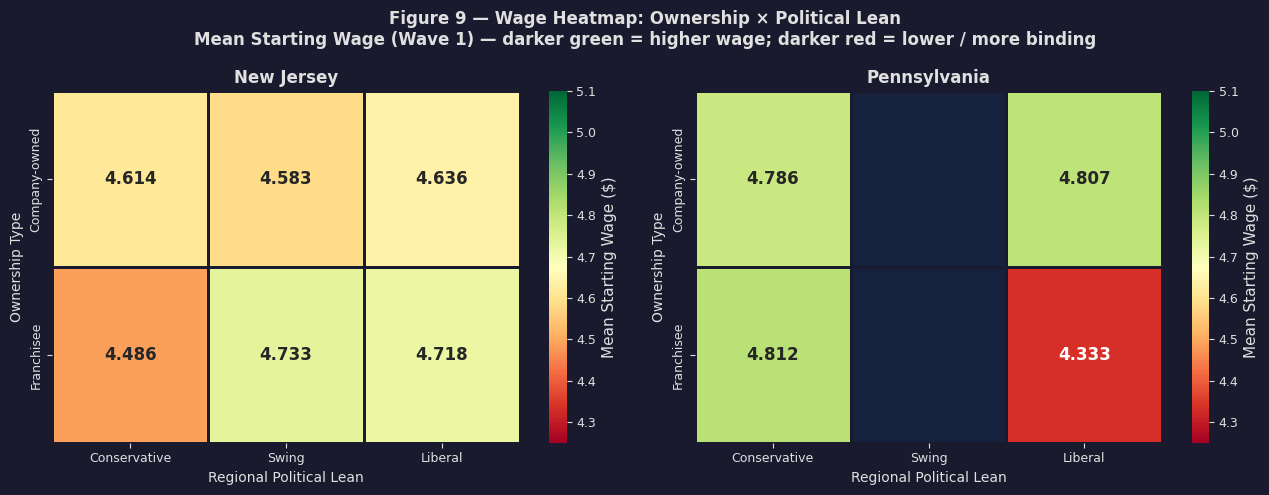

✓ Saved fig9_wage_heatmap.png


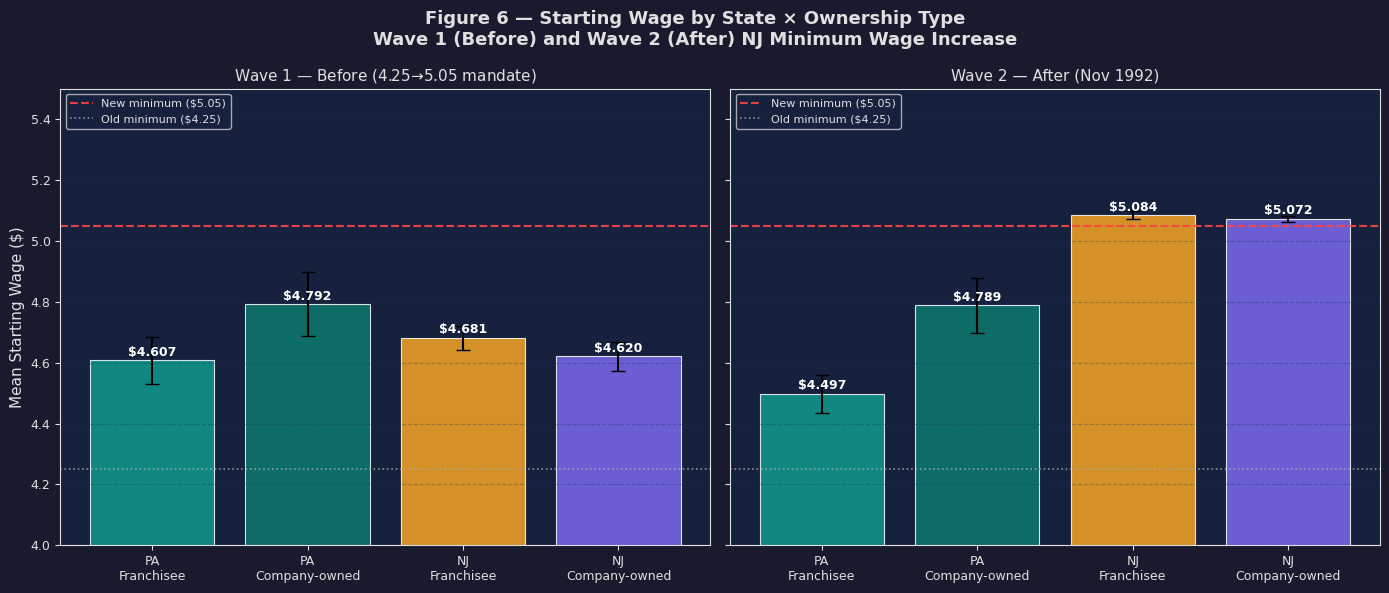

✓ Saved fig6_wage_by_ownership.png


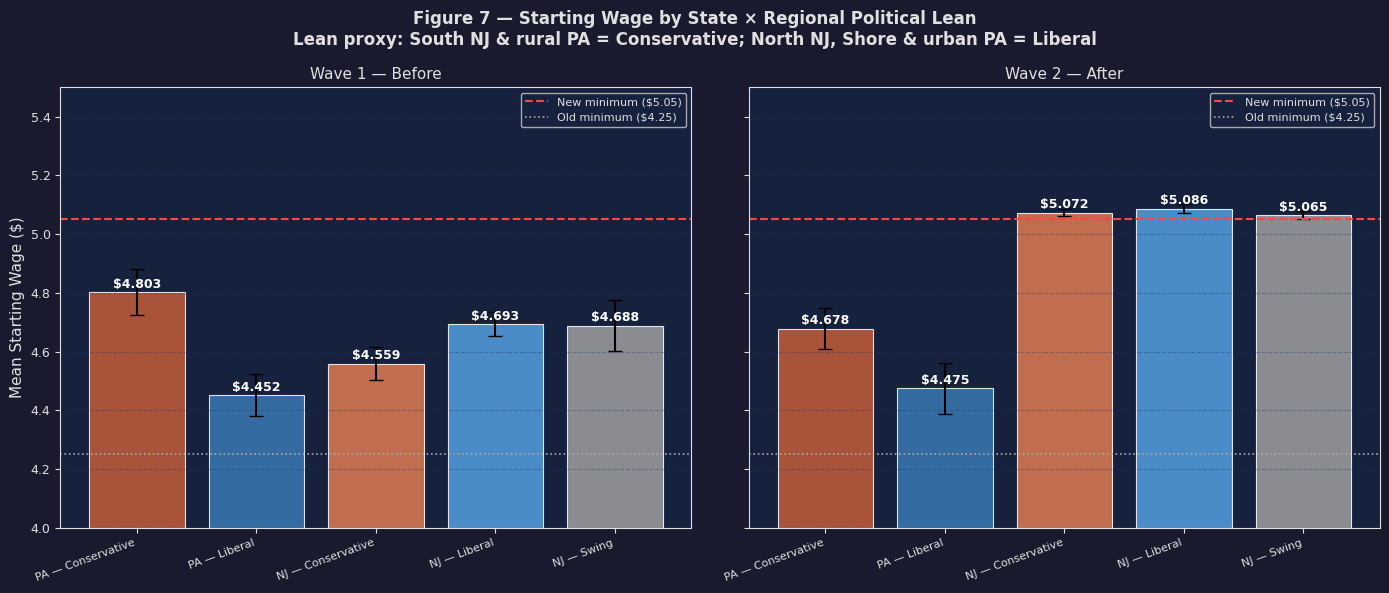

✓ Saved fig7_wage_by_region.png


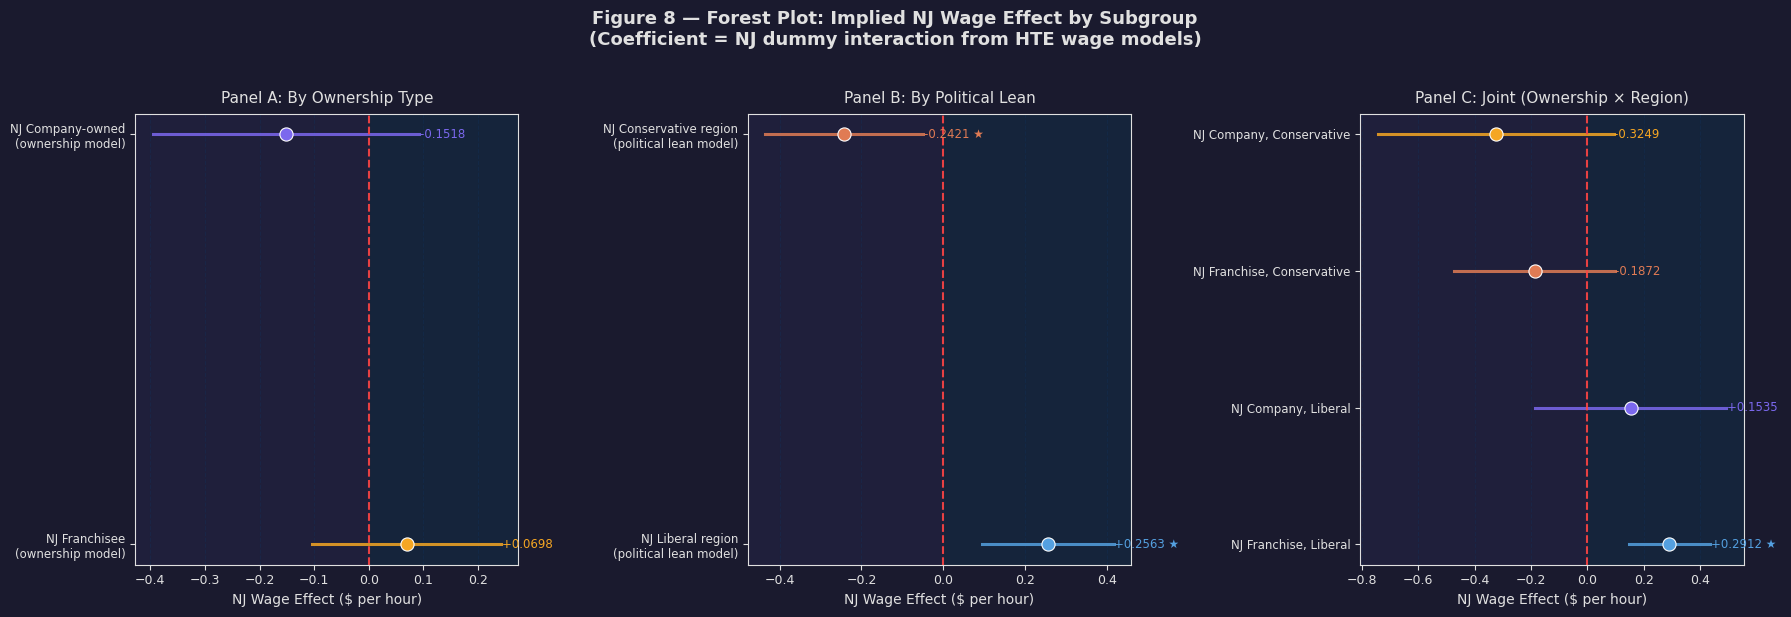

✓ Saved fig8_forest_wage_hte.png


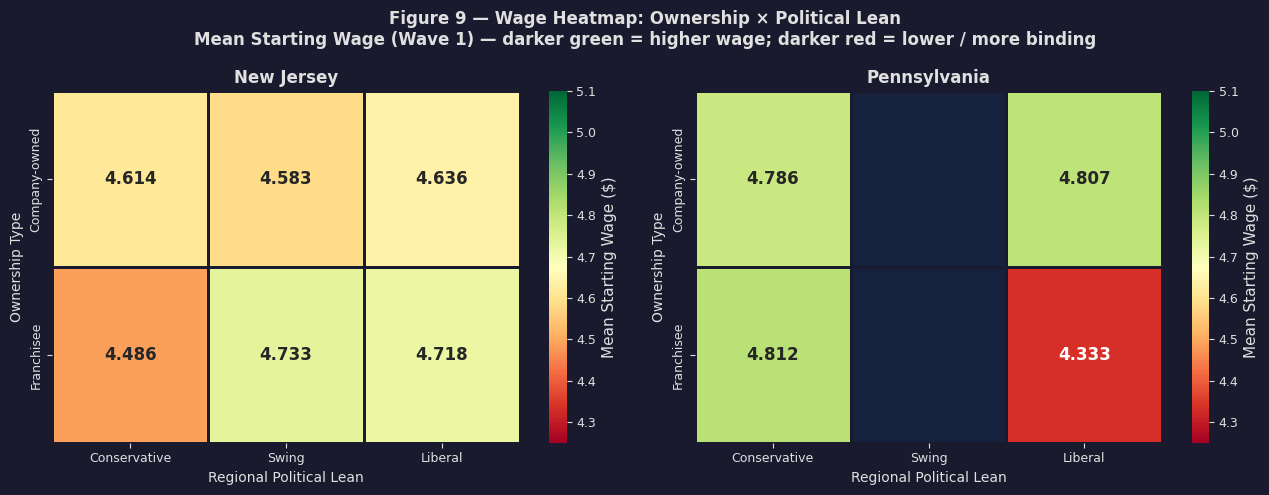

✓ Saved fig9_wage_heatmap.png


In [63]:
# =============================================================================
# PHASE 4 VISUALISATIONS
# Fig 6 — Mean wage by ownership × state
# Fig 7 — Mean wage by political lean × state
# Fig 8 — Forest plot: NJ wage effect by subgroup
# Fig 9 — Wage heatmap: ownership × region grid
# =============================================================================

def plot_wage_by_ownership(df):
    bal = df[df['balanced'] == 1].copy()
    bal['group'] = (
        bal['nj'].map({1: 'NJ', 0: 'PA'}) + '\n' +
        bal['co_owned'].map({1: 'Company-owned', 0: 'Franchisee'})
    )
    order = ['PA\nFranchisee', 'PA\nCompany-owned',
             'NJ\nFranchisee', 'NJ\nCompany-owned']
    palette = {
        'PA\nFranchisee':    COLORS['pa'],
        'PA\nCompany-owned': '#0d7a6e',
        'NJ\nFranchisee':    COLORS['franchise'],
        'NJ\nCompany-owned': COLORS['company'],
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(
        'Figure 6 — Starting Wage by State × Ownership Type\n'
        'Wave 1 (Before) and Wave 2 (After) NJ Minimum Wage Increase',
        fontsize=13, fontweight='bold'
    )

    for ax, (wave_col, title) in zip(axes, [
        ('wage_st',  'Wave 1 — Before ($4.25 → $5.05 mandate)'),
        ('wage_st2', 'Wave 2 — After (Nov 1992)'),
    ]):
        if wave_col not in bal.columns:
            ax.text(0.5, 0.5, f'{wave_col} not in dataset',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            continue

        means  = bal.groupby('group')[wave_col].mean().reindex(order)
        sems   = bal.groupby('group')[wave_col].sem().reindex(order)
        colors = [palette[g] for g in order]
        bars   = ax.bar(order, means, color=colors, alpha=0.85,
                        edgecolor='white', linewidth=0.8,
                        yerr=sems, capsize=5,
                        error_kw={'color': 'white', 'linewidth': 1.5})

        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'${val:.3f}', ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')

        ax.axhline(5.05, color=COLORS['zero_line'], linestyle='--',
                   linewidth=1.5, label='New minimum ($5.05)', alpha=0.9)
        ax.axhline(4.25, color='#aaaaaa', linestyle=':',
                   linewidth=1.2, label='Old minimum ($4.25)', alpha=0.8)
        ax.set_title(title, fontsize=11)
        ax.set_ylabel('Mean Starting Wage ($)' if ax == axes[0] else '')
        ax.set_ylim(4.0, 5.5)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig6_wage_by_ownership.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('✓ Saved fig6_wage_by_ownership.png')


def plot_wage_by_region(df):
    bal = df[df['balanced'] == 1].copy()
    bal['pol_label'] = np.select(
        [bal['conservative_region'] == 1,
         bal['liberal_region'] == 1,
         bal['swing_region'] == 1],
        ['Conservative', 'Liberal', 'Swing'],
        default='Unclassified'
    )
    bal['group'] = bal['nj'].map({1: 'NJ', 0: 'PA'}) + ' — ' + bal['pol_label']
    order = ['PA — Conservative', 'PA — Liberal',
             'NJ — Conservative', 'NJ — Liberal', 'NJ — Swing']
    palette = {
        'PA — Conservative': '#c45c3a',
        'PA — Liberal':      '#3a7ab5',
        'NJ — Conservative': COLORS['conservative'],
        'NJ — Liberal':      COLORS['liberal'],
        'NJ — Swing':        '#a0a0a0',
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(
        'Figure 7 — Starting Wage by State × Regional Political Lean\n'
        'Lean proxy: South NJ & rural PA = Conservative; North NJ, Shore & urban PA = Liberal',
        fontsize=12, fontweight='bold'
    )

    for ax, (wave_col, title) in zip(axes, [
        ('wage_st',  'Wave 1 — Before'),
        ('wage_st2', 'Wave 2 — After'),
    ]):
        if wave_col not in bal.columns:
            ax.text(0.5, 0.5, f'{wave_col} not in dataset',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            continue

        avail  = [g for g in order if g in bal['group'].unique()]
        means  = bal.groupby('group')[wave_col].mean().reindex(avail)
        sems   = bal.groupby('group')[wave_col].sem().reindex(avail)
        colors = [palette.get(g, '#888888') for g in avail]

        bars = ax.bar(avail, means, color=colors, alpha=0.85,
                      edgecolor='white', linewidth=0.8,
                      yerr=sems, capsize=5,
                      error_kw={'color': 'white', 'linewidth': 1.5})
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'${val:.3f}', ha='center', va='bottom',
                    fontsize=9, color='white', fontweight='bold')

        ax.axhline(5.05, color=COLORS['zero_line'], linestyle='--',
                   linewidth=1.5, label='New minimum ($5.05)')
        ax.axhline(4.25, color='#aaaaaa', linestyle=':',
                   linewidth=1.2, label='Old minimum ($4.25)')
        ax.set_title(title, fontsize=11)
        ax.set_ylabel('Mean Starting Wage ($)' if ax == axes[0] else '')
        ax.set_ylim(4.0, 5.5)
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)
        plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)

    plt.tight_layout()
    plt.savefig('fig7_wage_by_region.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('✓ Saved fig7_wage_by_region.png')


def plot_wage_forest(implied_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    fig.suptitle(
        'Figure 8 — Forest Plot: Implied NJ Wage Effect by Subgroup\n'
        '(Coefficient = NJ dummy interaction from HTE wage models)',
        fontsize=13, fontweight='bold', y=1.02
    )

    groups    = ['Ownership', 'Political Lean', 'Joint Model']
    subtitles = [
        'Panel A: By Ownership Type',
        'Panel B: By Political Lean',
        'Panel C: Joint (Ownership × Region)',
    ]

    for ax, group, subtitle in zip(axes, groups, subtitles):
        sub = implied_df[implied_df['Group'] == group].copy().reset_index(drop=True)
        y   = np.arange(len(sub))

        for i, row in sub.iterrows():
            ax.plot([row['CI_lower'], row['CI_upper']], [i, i],
                    color=row['Color'], linewidth=2.2, alpha=0.85)
            ax.scatter(row['Estimate'], i, color=row['Color'],
                       s=90, marker='o', zorder=3,
                       edgecolors='white', linewidths=0.8)
            sig = '★' if row['Significant'] else ''
            ax.text(row['CI_upper'] + 0.002, i,
                    f"{row['Estimate']:+.4f} {sig}",
                    va='center', fontsize=8.5, color=row['Color'])

        ax.axvline(0, color=COLORS['zero_line'], linestyle='--',
                   linewidth=1.5, alpha=0.9)
        ax.set_yticks(y)
        ax.set_yticklabels(sub['Label'], fontsize=8.5)
        ax.set_xlabel('NJ Wage Effect ($ per hour)', fontsize=10)
        ax.set_title(subtitle, fontsize=11, pad=8)
        ax.grid(True, axis='x', alpha=0.3)
        xlim = ax.get_xlim()
        ax.axvspan(0, xlim[1], alpha=0.04, color='green')
        ax.axvspan(xlim[0], 0, alpha=0.04, color='red')
        ax.set_xlim(xlim)

    plt.tight_layout()
    plt.savefig('fig8_forest_wage_hte.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('✓ Saved fig8_forest_wage_hte.png')


def plot_wage_heatmap(df):
    bal = df[df['balanced'] == 1].copy()

    # Build label columns as plain strings first
    bal['own_label'] = bal['co_owned'].map({1: 'Company-owned', 0: 'Franchisee'})
    bal['pol_label'] = np.select(
        [bal['conservative_region'] == 1, bal['liberal_region'] == 1],
        ['Conservative', 'Liberal'], default='Swing'
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        'Figure 9 — Wage Heatmap: Ownership × Political Lean\n'
        'Mean Starting Wage (Wave 1) — darker green = higher wage; darker red = lower / more binding',
        fontsize=12, fontweight='bold'
    )

    own_order = ['Company-owned', 'Franchisee']
    pol_order = ['Conservative', 'Swing', 'Liberal']

    for ax, (state_val, state_label) in zip(axes, [(1, 'New Jersey'), (0, 'Pennsylvania')]):
        sub = bal[bal['nj'] == state_val].copy()

        # Pivot using plain string columns
        pivot = sub.pivot_table(
            values='wage_st',
            index='own_label',
            columns='pol_label',
            aggfunc='mean'
        )

        # Reindex to enforce row/column order; missing cells become NaN
        pivot = pivot.reindex(index=own_order, columns=pol_order)

        sns.heatmap(
            pivot, ax=ax,
            cmap='RdYlGn', vmin=4.25, vmax=5.10,
            annot=True, fmt='.3f', annot_kws={'size': 12, 'weight': 'bold'},
            linewidths=0.8, linecolor='#1a1a2e',
            cbar_kws={'label': 'Mean Starting Wage ($)'},
            mask=pivot.isna()   # grey-out cells with no data (e.g. PA Swing)
        )
        ax.set_title(state_label, fontsize=12, fontweight='bold')
        ax.set_xlabel('Regional Political Lean', fontsize=10)
        ax.set_ylabel('Ownership Type', fontsize=10)

    plt.tight_layout()
    plt.savefig('fig9_wage_heatmap.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('✓ Saved fig9_wage_heatmap.png')


plot_wage_heatmap(df)

# ── Run all Phase 4 visualisations ───────────────────────────────────────────
plot_wage_by_ownership(df)
plot_wage_by_region(df)
plot_wage_forest(implied_wage)
plot_wage_heatmap(df)